In [1]:
#setting device
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
import numpy as np

X_train = np.load('../processed/X_train.npy')
X_test  = np.load('../processed/X_test.npy')
y_train = np.load('../processed/y_train.npy')
y_test  = np.load('../processed/y_test.npy')

print("X_train shape:", X_train.shape)
print("y_trian shape:", y_train.shape)

X_train shape: (640000, 78)
y_trian shape: (640000,)


In [3]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [4]:
#dataset & dataloader
from torch.utils.data import Dataset, TensorDataset, DataLoader

class CICDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

In [5]:
#building model(MLP)
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [6]:
#initializing
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

model = MLP(input_dim, num_classes)

model = model.to(device)

In [7]:
#loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
#training loop
epochs = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")

Epoch [1/10], Loss: 213.4096
Epoch [2/10], Loss: 95.4874
Epoch [3/10], Loss: 76.0772
Epoch [4/10], Loss: 68.3046
Epoch [5/10], Loss: 56.2443
Epoch [6/10], Loss: 52.2693
Epoch [7/10], Loss: 55.9480
Epoch [8/10], Loss: 57.6541
Epoch [9/10], Loss: 50.9842
Epoch [10/10], Loss: 52.5392


/home/echo/miniconda3/envs/ai_security/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/echo/miniconda3/envs/ai_security/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/echo/miniconda3/envs/ai_security/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

              precision    recall  f1-score   support

           0       0.98      0.99      0.98    128426
           1       1.00      0.03      0.06       101
           2       0.93      0.98      0.95      7272
           3       0.94      0.93      0.94       583
           4       0.97      0.85      0.91     13067
           5       0.70      0.73      0.71       300
           6       0.93      0.59      0.72       323
           7       0.98      0.61      0.76       464
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         2
          10       0.91      0.93      0.92      8993
          11       0.99      0.49      0.66       338
          12       0.00      0.00      0.00        94
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00        34

    accuracy                           0.97    160000
   macro avg       0.62      0.48      0.51    160000
weighted avg       0.97   

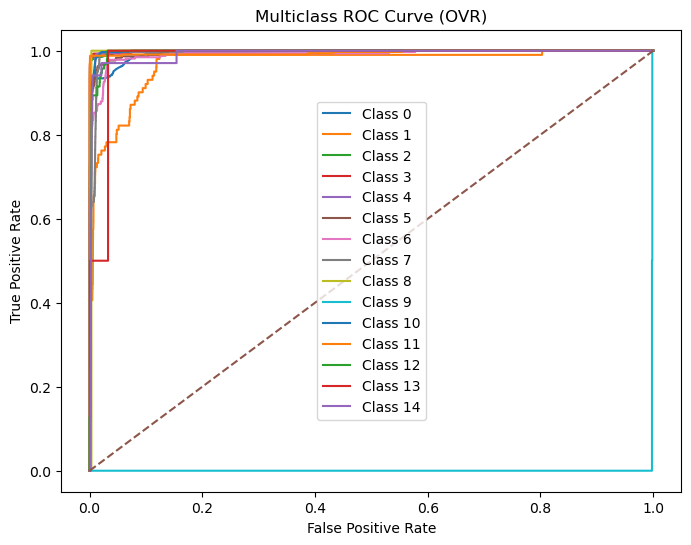

In [9]:
#evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()
all_preds = []
all_labels = []
all_probs = []



with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)

        probs = F.softmax(outputs, dim=1)
        positive_probs = probs[:,]

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(positive_probs.numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

n_classes = all_probs.shape[1]
unique_classes = np.unique(all_labels)
y_true_bin = label_binarize(all_labels, classes=np.arange(n_classes))

y_true_bin = y_true_bin[:, unique_classes]
all_probs_unique = all_probs[:, unique_classes]


print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
print(cm)

roc_auc = roc_auc_score(
    y_true_bin,
    all_probs_unique,
    multi_class="ovr",
    average="macro"
)
print("ROC-AUC:", roc_auc)

#ROC Curve
plt.figure(figsize=(8, 6))

for idx, cls in enumerate(unique_classes):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, idx],
        all_probs_unique[:, idx]
    )
    plt.plot(fpr, tpr, label=f"Class {idx}")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (OVR)")
plt.legend()
plt.show()

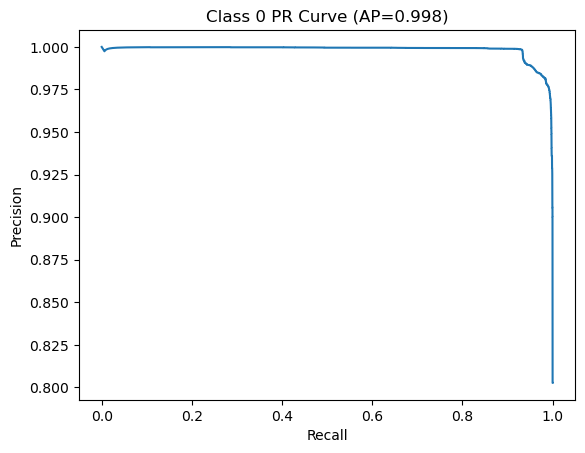

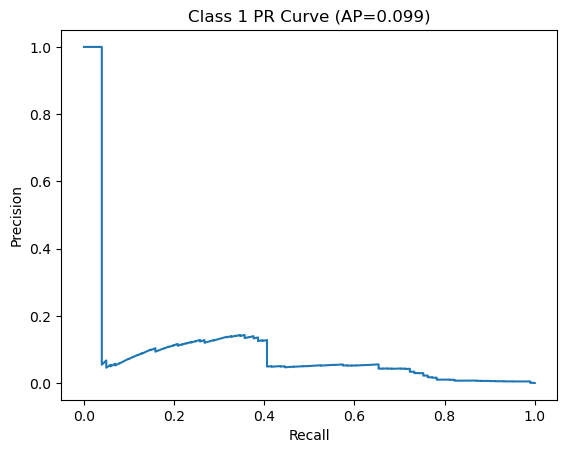

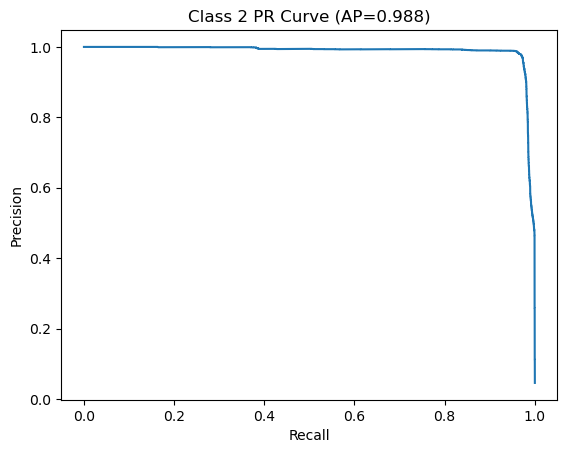

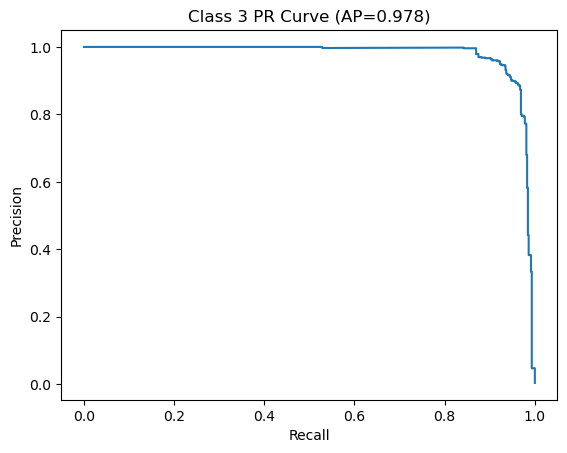

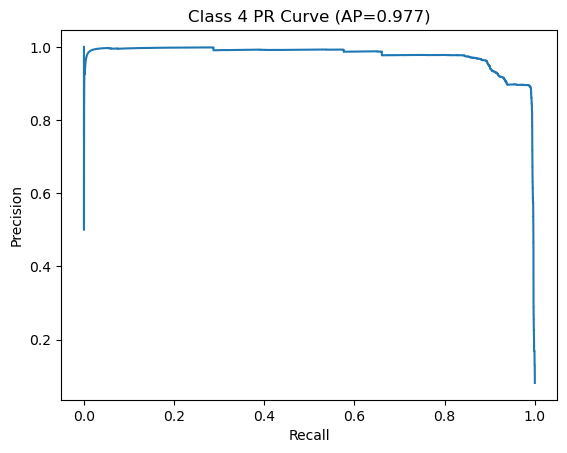

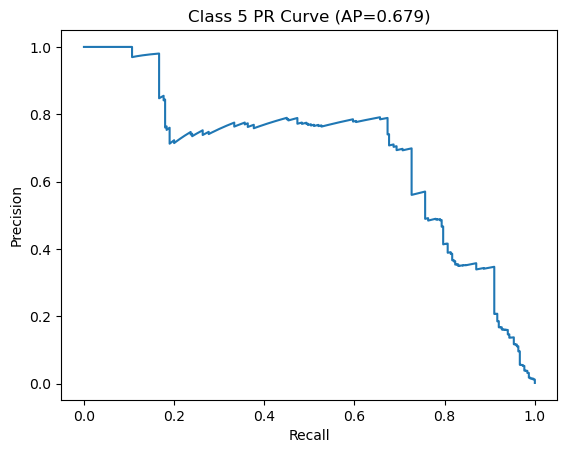

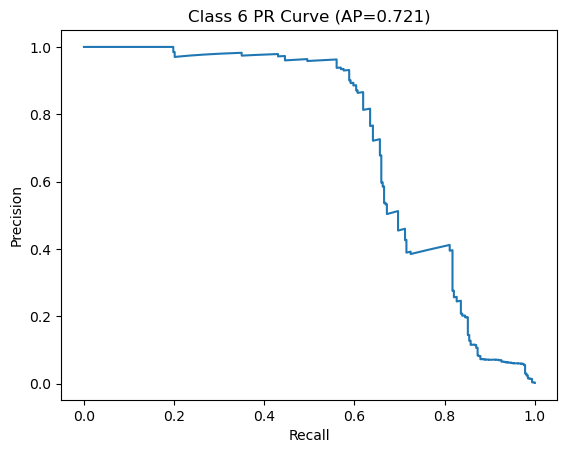

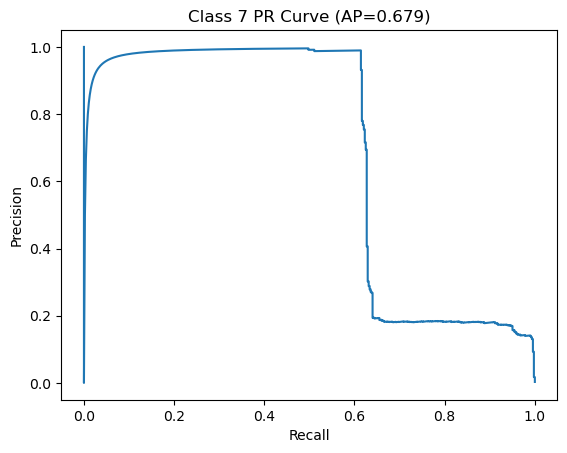

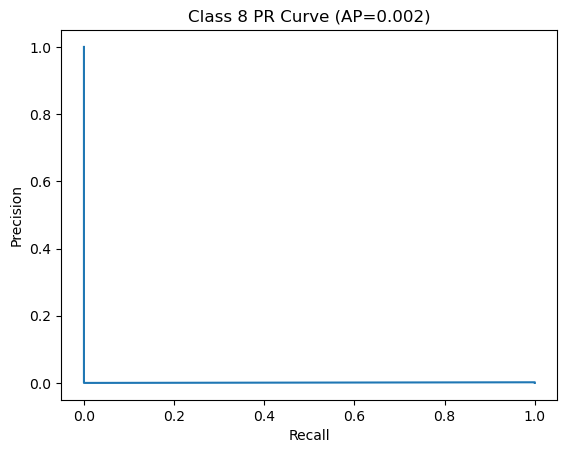

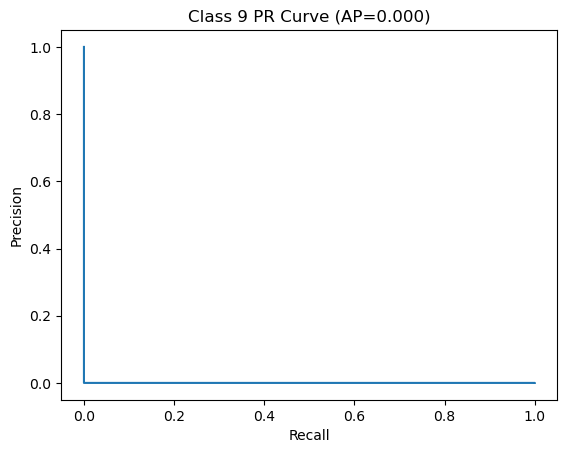

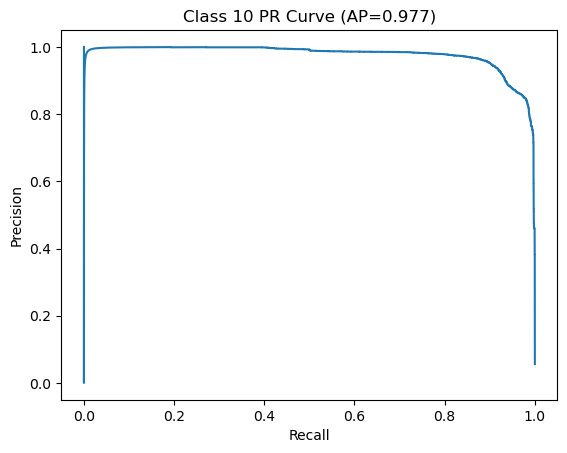

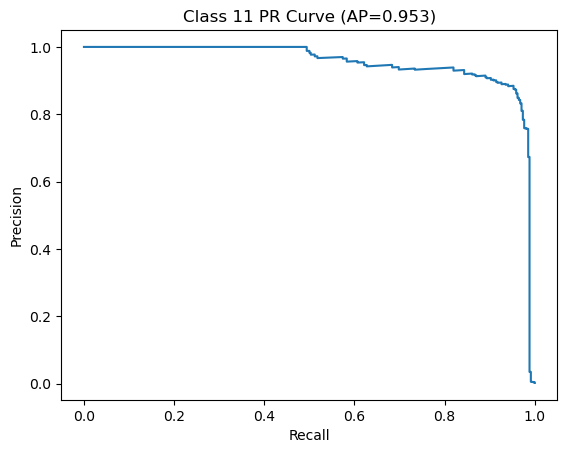

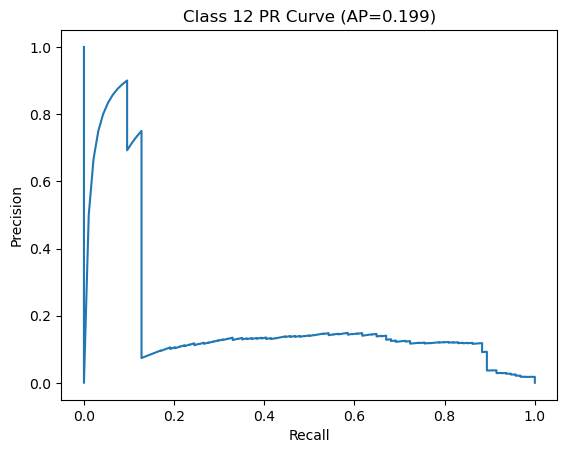

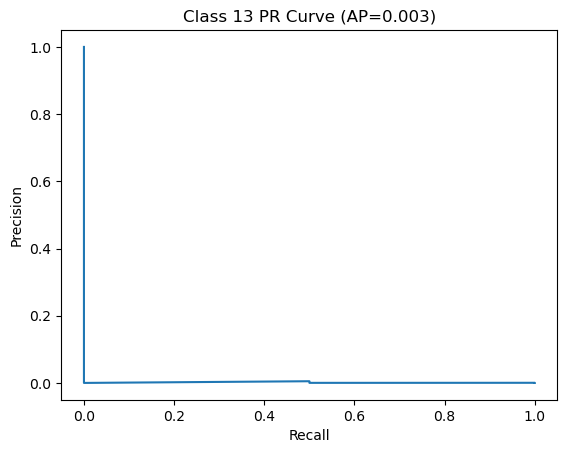

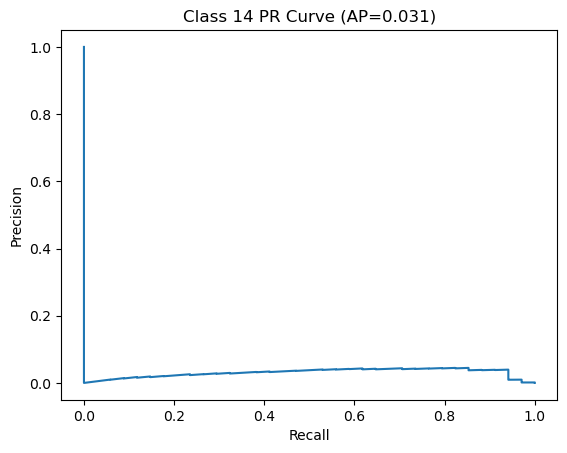

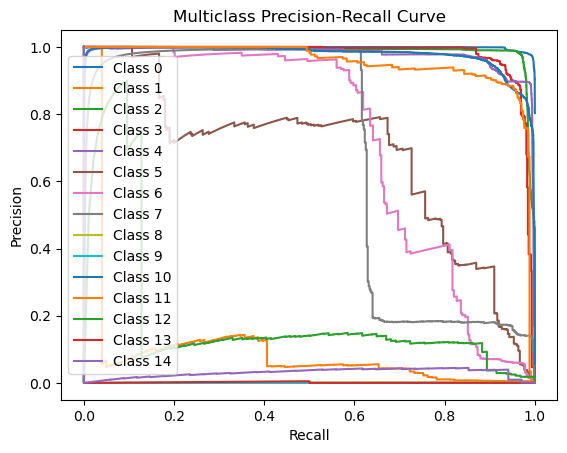

In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

y_true_bin = label_binarize(all_labels, classes=np.unique(all_labels))
n_classes = y_true_bin.shape[1]

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        all_probs[:, i]
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        all_probs[:, i]
    )

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Class {i} PR Curve (AP={ap:.3f})")
    plt.show()

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        all_probs[:, i]
    )
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Multiclass Precision-Recall Curve")
plt.show()

In [11]:
#Class distribution
import pandas as pd

y_train_series = pd.Series(y_train)

class_distribution = pd.DataFrame({
    "count": y_train_series.value_counts(),
    "ratio (%)": y_train_series.value_counts(normalize=True) * 100
}).sort_index()

print(class_distribution)

     count  ratio (%)
0   513705  80.266406
1      403   0.062969
2    29088   4.545000
3     2333   0.364531
4    52268   8.166875
5     1202   0.187812
6     1294   0.202187
7     1855   0.289844
8        3   0.000469
9        9   0.001406
10   35971   5.620469
11    1354   0.211562
12     375   0.058594
13       5   0.000781
14     135   0.021094


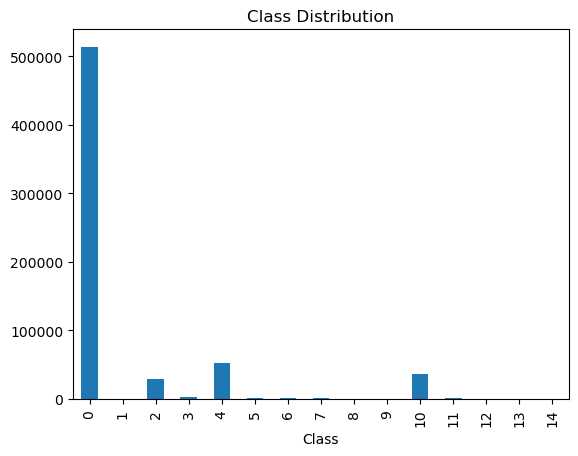

In [12]:
#Bar plot
import matplotlib.pyplot as plt
import pandas as pd

class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure()
class_counts.plot(kind='bar')
plt.xlabel("Class")
plt.ylabel
("Number of Samples")
plt.title("Class Distribution")
plt.show()

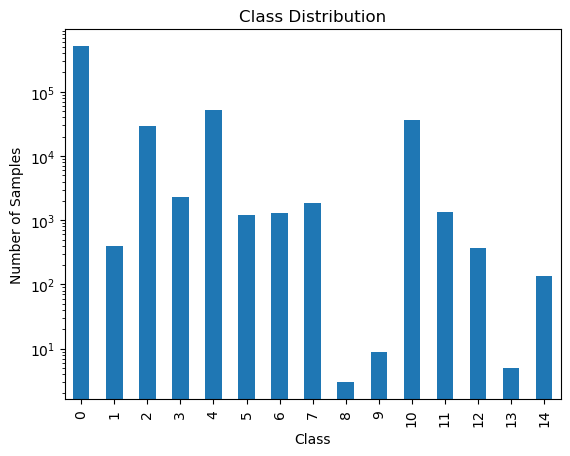

In [13]:
#Bar plot_log scale
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure()
class_counts.plot(kind='bar')
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.yscale('log')
plt.title("Class Distribution")
plt.show()

In [14]:
#saving model
best_auc = 0

if roc_auc > best_auc:
    best_auc = roc_auc
    torch.save(model.state_dict(), "best_model.pth")